# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) - Lekcja 4</span>

1. [Mini-projekt: opóźnienia lotów](#1.-Mini-projekt:-opóźnienia-lotów)
2. [Najważniejsze operacje w praktyce](#2.-Najważniejsze-operacje-w-praktyce)
3. [Dane i przygotowanie środowiska](#3.-Dane-i-przygotowanie-środowiska)
4. [Zadania obowiązkowe (1-15)](#4.-Zadania-obowiązkowe-(1-15))
5. [Zadania dodatkowe (16-24)](#5.-Zadania-dodatkowe-(16-24))
6. [Najczęstsze błędy](#Najczęstsze-błędy)


# <span style="color:#0f766e; font-weight:700;">1. Mini-projekt: opóźnienia lotów</span>

W tej lekcji pracujemy na publicznym zbiorze **nycflights13**. To duży, realistyczny zestaw danych, który dobrze domyka materiał z lekcji 1-3:
- lekcja 1: import i organizacja pracy,
- lekcja 2: statystyka opisowa i wizualizacje,
- lekcja 3: operacje na `DataFrame`, łączenie tabel i reshaping.

Tutaj dokładamy pełny pipeline analityczny:
- audyt jakości danych,
- czyszczenie braków i wartości spoza zakresu,
- bezpieczne merge wielu tabel,
- budowę cech z czasu i opóźnień,
- odpowiedzi na pytania badawcze,
- krótki raport końcowy.

## <span style="color:#0f766e; font-weight:700;">Pytania badawcze Q1-Q5</span>

- Q1: Którzy przewoźnicy mają najniższe typowe opóźnienia odlotu przy sensownej liczebności lotów?
- Q2: Które kierunki mają najwyższe średnie opóźnienia przylotu?
- Q3: Jak warunki pogodowe wiążą się z opóźnieniami odlotu?
- Q4: Jak zmienia się punktualność w czasie: miesiąc, dzień tygodnia i godzina?
- Q5: Ile rekordów odrzuciliśmy podczas czyszczenia i dlaczego?


# <span style="color:#0f766e; font-weight:700;">2. Najważniejsze operacje w praktyce</span>



Najważniejsze operacje tej lekcji:
- `query()`, `loc[]`, `iloc[]` do czytelnego wybierania rekordów,
- `assign()`, `rename()`, `sort_values()`, `set_index()` do budowy pipeline'u,
- `groupby()`, `agg()`, `value_counts()`, `nunique()` do podsumowań,
- `merge(..., validate=...)` do bezpiecznego łączenia,
- `melt()`, `pivot_table()`, `crosstab()` do zmiany kształtu danych,
- `pd.to_datetime()` i `.dt` do pracy z czasem,
- `matplotlib` i `seaborn` do szybkich wykresów roboczych.


## <span style="color:#0f766e; font-weight:700;">Przykład 1: Tabele referencyjne i szybka diagnostyka</span>

Na początek warto zobaczyć, jak wyglądają mniejsze tabele pomocnicze. Dzięki temu łatwiej później planować sensowne merge.


In [1]:
%pip install nycflights13
%pip install "setuptools<82"
from IPython.display import display

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [81]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd


# Rozpoczynamy blok bezpiecznego importu danych.
try:
    # Importujemy z pakietu tylko te tabele, które będą potrzebne w tym fragmencie.
    from nycflights13 import airlines, airports, planes,weather
# Obsługujemy sytuację, w której pakiet z danymi nie jest dostępny.
except ImportError as exc:
    # Zwracamy czytelny komunikat z instrukcją instalacji pakietu.
    raise ImportError("Zainstaluj pakiet: pip install nycflights13") from exc

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("airlines:", airlines.shape)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(airlines.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("airports:", airports.shape)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(airports[["faa", "name", "tz", "tzone"]].head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print("planes:", planes.shape)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes[["tailnum", "manufacturer", "model", "seats"]].head())


airlines: (16, 2)
  carrier                    name
0      9E       Endeavor Air Inc.
1      AA  American Airlines Inc.
2      AS    Alaska Airlines Inc.
3      B6         JetBlue Airways
4      DL    Delta Air Lines Inc.

airports: (1458, 8)
   faa                           name  tz             tzone
0  04G              Lansdowne Airport  -5  America/New_York
1  06A  Moton Field Municipal Airport  -6   America/Chicago
2  06C            Schaumburg Regional  -6   America/Chicago
3  06N                Randall Airport  -5  America/New_York
4  09J          Jekyll Island Airport  -5  America/New_York

planes: (3322, 9)
  tailnum      manufacturer      model  seats
0  N10156           EMBRAER  EMB-145XR     55
1  N102UW  AIRBUS INDUSTRIE   A320-214    182
2  N103US  AIRBUS INDUSTRIE   A320-214    182
3  N104UW  AIRBUS INDUSTRIE   A320-214    182
4  N10575           EMBRAER  EMB-145LR     55


## <span style="color:#0f766e; font-weight:700;">Przykład 2: Wybieranie kolumn, filtrowanie, `query`, `loc`, `iloc`</span>

Najpierw ćwiczymy czyste operacje na fragmentach danych.


In [4]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Importujemy z pakietu tylko te tabele, które będą potrzebne w tym fragmencie.
from nycflights13 import flights

# Tworzymy tabelę `flights_day1` przez filtrowanie danych i zapisujemy wynik jako niezależną kopię.
flights_day1 = flights.query("month == 1 and day == 1").copy()

# Zapisujemy wynik bieżącej operacji do zmiennej `selected_day1`.
selected_day1 = flights_day1[["carrier", "origin", "dest", "distance", "air_time", "dep_delay"]]
# Wyświetlamy nagłówek lub komunikat: '"WYBRANE KOLUMNY:'.
print("WYBRANE KOLUMNY:")

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Zapisujemy wynik bieżącej operacji do zmiennej `long_haul_day1`.
long_haul_day1 = selected_day1.query("distance >= 1500 and air_time >= 200")
# Wyświetlamy nagłówek lub komunikat: '"LOTY DALEKIEGO ZASIĘGU:'.
print("LOTY DALEKIEGO ZASIĘGU:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(long_haul_day1.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy nagłówek lub komunikat: '"LOC:'.
print("LOC:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.loc[selected_day1.index[:4], ["carrier", "dest", "distance"]])
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy nagłówek lub komunikat: '"ILOC:'.
print("ILOC:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(selected_day1.iloc[:4, :3])


WYBRANE KOLUMNY:
  carrier origin dest  distance  air_time  dep_delay
0      UA    EWR  IAH      1400     227.0        2.0
1      UA    LGA  IAH      1416     227.0        4.0
2      AA    JFK  MIA      1089     160.0        2.0
3      B6    JFK  BQN      1576     183.0       -1.0
4      DL    LGA  ATL       762     116.0       -6.0

LOTY DALEKIEGO ZASIĘGU:
   carrier origin dest  distance  air_time  dep_delay
12      UA    JFK  LAX      2475     345.0       -2.0
13      UA    EWR  SFO      2565     361.0       -2.0
16      UA    EWR  LAS      2227     337.0       -1.0
26      UA    JFK  SFO      2586     366.0       11.0
30      US    EWR  PHX      2133     342.0       -8.0

LOC:
  carrier dest  distance
0      UA  IAH      1400
1      UA  IAH      1416
2      AA  MIA      1089
3      B6  BQN      1576

ILOC:
  carrier origin dest
0      UA    EWR  IAH
1      UA    LGA  IAH
2      AA    JFK  MIA
3      B6    JFK  BQN


## <span style="color:#0f766e; font-weight:700;">Przykład 3: Transformacje i nowe kolumny z `sched_dep_time`</span>

Tu ćwiczymy `assign()`, `rename()` i `sort_values()` na problemie pobocznym: jak czytać godziny zapisane jako liczby `HHMM`.


In [5]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `schedule_demo`.
schedule_demo = flights.head(12).copy()
# Zmieniamy nazwy wybranych kolumn i zapisujemy wynik do `schedule_demo`.
schedule_demo = schedule_demo.rename(columns={"distance": "distance_miles"})
# Tworzymy lub nadpisujemy kolumnę `sched_dep_hour` w tabeli `schedule_demo`.
schedule_demo["sched_dep_hour"] = schedule_demo["sched_dep_time"] // 100
# Tworzymy lub nadpisujemy kolumnę `sched_dep_minute` w tabeli `schedule_demo`.
schedule_demo["sched_dep_minute"] = schedule_demo["sched_dep_time"] % 100
# Tworzymy lub nadpisujemy kolumnę `sched_arr_hour` w tabeli `schedule_demo`.
schedule_demo["sched_arr_hour"] = schedule_demo["sched_arr_time"] // 100
# Tworzymy lub nadpisujemy kolumnę `sched_arr_minute` w tabeli `schedule_demo`.
schedule_demo["sched_arr_minute"] = schedule_demo["sched_arr_time"] % 100
# Tworzymy lub nadpisujemy kolumnę `distance_km` w tabeli `schedule_demo`.
schedule_demo["distance_km"] = (schedule_demo["distance_miles"] * 1.609).round(1)
# Łączymy dwa kody lotnisk w jeden napis i zapisujemy go w kolumnie `route`.
schedule_demo["route"] = schedule_demo["origin"] + "-" + schedule_demo["dest"]
# Porządkujemy obiekt `schedule_demo` zgodnie z podaną regułą sortowania.
schedule_demo = schedule_demo.sort_values(["sched_dep_hour", "sched_dep_minute"])
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(schedule_demo[["route", "sched_dep_time", "sched_dep_hour", "sched_dep_minute", "distance_km"]])


      route  sched_dep_time  sched_dep_hour  sched_dep_minute  distance_km
0   EWR-IAH             515               5                15       2252.6
1   LGA-IAH             529               5                29       2278.3
2   JFK-MIA             540               5                40       1752.2
3   JFK-BQN             545               5                45       2535.8
5   EWR-ORD             558               5                58       1156.9
4   LGA-ATL             600               6                 0       1226.1
6   EWR-FLL             600               6                 0       1713.6
7   LGA-IAD             600               6                 0        368.5
8   JFK-MCO             600               6                 0       1518.9
9   LGA-ORD             600               6                 0       1179.4
10  JFK-PBI             600               6                 0       1654.1
11  JFK-TPA             600               6                 0       1617.0


## <span style="color:#0f766e; font-weight:700;">Przykład 4: `groupby`, `agg`, `nunique` na pytaniu pobocznym</span>

Zamiast analizować ogólne opóźnienia, policzymy ile czasu loty potrafiły „odrobić” w powietrzu.


In [ ]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy tabelę `recovery_demo` po usunięciu rekordów z brakami w wybranych kolumnach.
recovery_demo = flights.dropna(subset=["dep_delay", "arr_delay", "carrier", "origin"]).copy()
# Obliczamy i zapisujemy w kolumnie `delay_recovery` różnicę między dwiema zmiennymi.
recovery_demo["delay_recovery"] = recovery_demo["dep_delay"] - recovery_demo["arr_delay"]
# Budujemy tabelę `recovery_summary` z agregacjami policzonymi dla każdej grupy.
recovery_summary = recovery_demo.groupby(["carrier", "origin"]).agg(
    # Zapisujemy wynik bieżącej operacji do zmiennej `flights_n`.
    flights_n=("flight", "count"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `routes_n`.
    routes_n=("dest", "nunique"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `recovery_mean`.
    recovery_mean=("delay_recovery", "mean"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `recovery_median`.
    recovery_median=("delay_recovery", "median"),
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(recovery_summary.sort_values("recovery_mean", ascending=False).head(12).round(2))


## <span style="color:#0f766e; font-weight:700;">Przykład 5: `merge()` z tabelą `planes`</span>

Ćwiczymy merge na innym pytaniu niż w projekcie: jak wygląda rozkład liczby miejsc w samolotach używanych przez wybranych przewoźników.


In [66]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy tabelę `planes_demo` przez filtrowanie danych i zapisujemy wynik jako niezależną kopię.
planes_demo = flights.query("carrier in ['AA', 'DL', 'UA']").head(2000).copy()

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `planes_lookup`.
planes_lookup = planes[["tailnum", "manufacturer", "model", "seats", "engine"]].copy()

# Tworzymy obiekt `planes_demo` przez połączenie dwóch tabel na wspólnym kluczu.
planes_demo = planes_demo.merge(
    # Przekazujemy obiekt `planes_lookup` jako argument do bieżącej funkcji.
    planes_lookup,
    # Parametr `on` wskazuje kolumnę lub listę kolumn używanych jako klucz łączenia.
    on="tailnum",
    # Parametr `how` określa typ połączenia tabel i to, które rekordy zostają zachowane.
    how="left",
    # Parametr `validate` sprawdza, czy relacja między kluczami ma oczekiwaną strukturę.
    validate="many_to_one",
    # Parametr `indicator` dodaje kolumnę z informacją o źródle dopasowania po merge.
    indicator="merge_planes",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes_demo["merge_planes"].value_counts())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()

# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(planes_demo[["carrier", "tailnum", "manufacturer", "model", "seats", "merge_planes"]].head(12))


merge_planes
both          1628
left_only      372
right_only       0
Name: count, dtype: int64

   carrier tailnum                   manufacturer      model  seats  \
0       UA  N14228                         BOEING    737-824  149.0   
1       UA  N24211                         BOEING    737-824  149.0   
2       AA  N619AA                         BOEING    757-223  178.0   
3       DL  N668DN                         BOEING    757-232  178.0   
4       UA  N39463                         BOEING  737-924ER  191.0   
5       AA  N3ALAA                            NaN        NaN    NaN   
6       UA  N29129                         BOEING    757-224  178.0   
7       UA  N53441                         BOEING  737-924ER  191.0   
8       AA  N3DUAA                            NaN        NaN    NaN   
9       UA  N76515                         BOEING    737-824  149.0   
10      DL  N971DL  MCDONNELL DOUGLAS AIRCRAFT CO      MD-88  142.0   
11      AA  N633AA                         BOEING  

## <span style="color:#0f766e; font-weight:700;">Przykład 6: `melt()` i `pivot_table()` na podsumowaniu miesięcznym</span>

To jest dobry moment, żeby przypomnieć zmianę kształtu danych z lekcji 3.


In [65]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Budujemy tabelę `monthly_origin_demo` z agregacjami policzonymi dla każdej grupy.
monthly_origin_demo = flights.dropna(subset=["dep_delay", "arr_delay"]).groupby(["month", "origin"]).agg(
    # Zapisujemy wynik bieżącej operacji do zmiennej `dep_delay_mean`.
    dep_delay_mean=("dep_delay", "mean"),
    # Zapisujemy wynik bieżącej operacji do zmiennej `arr_delay_mean`.
    arr_delay_mean=("arr_delay", "mean"),
# Zamykamy agregację i zamieniamy indeks grupowania z powrotem na zwykłe kolumny.
).reset_index()

# Tworzymy tabelę przestawną i zapisujemy ją jako `monthly_origin_pivot`.
monthly_origin_pivot = monthly_origin_demo.pivot_table(
    # Parametr `index` wskazuje, co ma trafić do wierszy wyniku.
    index="month",
    # Parametr `columns` ustawia kolumny w wyniku albo słownik zmian nazw kolumn.
    columns="origin",
    # Parametr `values` wybiera zmienną, która ma być agregowana lub pokazana w tabeli.
    values="dep_delay_mean",
    # Parametr `aggfunc` określa funkcję agregującą używaną przy budowie tabeli.
    aggfunc="mean",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Zapisujemy wynik bieżącej operacji do zmiennej `monthly_origin_long`.
monthly_origin_long = monthly_origin_pivot.reset_index().melt(
    # Parametr `id_vars` wskazuje kolumny, które mają pozostać identyfikatorami po stopieniu tabeli.
    id_vars="month",
    # Parametr `var_name` ustawia nazwę kolumny z dawnymi nagłówkami po operacji `melt`.
    var_name="origin",
    # Parametr `value_name` ustawia nazwę kolumny z wartościami po operacji `melt`.
    value_name="dep_delay_mean",
# Domykamy bieżące wyrażenie lub blok parametrów.
)

# Wyświetlamy nagłówek lub komunikat: '"PIVOT:'.
print("PIVOT:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(monthly_origin_pivot.head())
# Wstawiamy pustą linię, aby oddzielić kolejne fragmenty wyniku.
print()
# Wyświetlamy nagłówek lub komunikat: '"MELT:'.
print("MELT:")
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(monthly_origin_long.head(12))


PIVOT:
origin        EWR        JFK        LGA
month                                  
1       14.855657   8.557635   5.607147
2       12.995452  11.736605   6.921184
3       18.050624  10.670843  10.153993
4       17.255987  12.214801  11.430409
5       15.228768  12.495038  10.506955

MELT:
    month origin  dep_delay_mean
0       1    EWR       14.855657
1       2    EWR       12.995452
2       3    EWR       18.050624
3       4    EWR       17.255987
4       5    EWR       15.228768
5       6    EWR       22.338537
6       7    EWR       21.858977
7       8    EWR       13.408123
8       9    EWR        7.142170
9      10    EWR        8.636918
10     11    EWR        6.721649
11     12    EWR       20.911902


## <span style="color:#0f766e; font-weight:700;">Przykład 7: `pd.to_datetime()`, `.dt` i `crosstab()`</span>

Na tym przykładzie ćwiczymy pracę z czasem oraz tabelę przekrojową.


In [64]:
# Importujemy bibliotekę pandas do pracy z tabelami.
import pandas as pd

# Tworzymy niezależną kopię danych i zapisujemy ją w zmiennej `time_demo`.
time_demo = flights.head(5000).copy()
# Nadpisujemy kolumnę `time_hour` w tabeli `time_demo` po konwersji do typu datetime.
time_demo["time_hour"] = pd.to_datetime(time_demo["time_hour"], utc=True)
# Zapisujemy do kolumny `quarter` cechę czasu wyliczoną z daty.
time_demo["quarter"] = time_demo["time_hour"].dt.quarter
# Zapisujemy do kolumny `weekday` cechę czasu wyliczoną z daty.
time_demo["weekday"] = time_demo["time_hour"].dt.day_name()
# Tworzymy w kolumnie `is_weekend` flagę na podstawie sprawdzenia przynależności do listy.
time_demo["is_weekend"] = time_demo["weekday"].isin(["Saturday", "Sunday"])
# Tworzymy tabelę krzyżową i zapisujemy wynik do `weekend_table`.
weekend_table = pd.crosstab(
    # Przekazujemy jedną z kolumn wejściowych do tabeli krzyżowej.
    time_demo["quarter"],
    # Przekazujemy jedną z kolumn wejściowych do tabeli krzyżowej.
    time_demo["is_weekend"],
    # Parametr `normalize` zamienia liczebności na udziały według wskazanego kierunku normalizacji.
    normalize="index",
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Wyświetlamy wynik bieżącego kroku, aby go od razu skontrolować.
print(weekend_table)


is_weekend   False   True 
quarter                   
1           0.6948  0.3052


## <span style="color:#0f766e; font-weight:700;">Przykład 8: Dwa wykresy robocze</span>




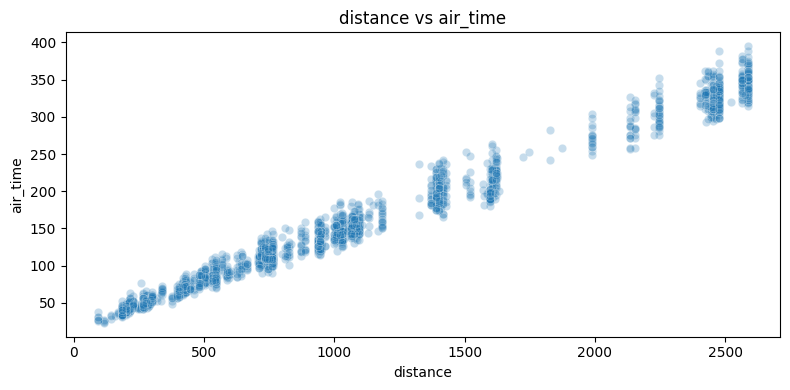

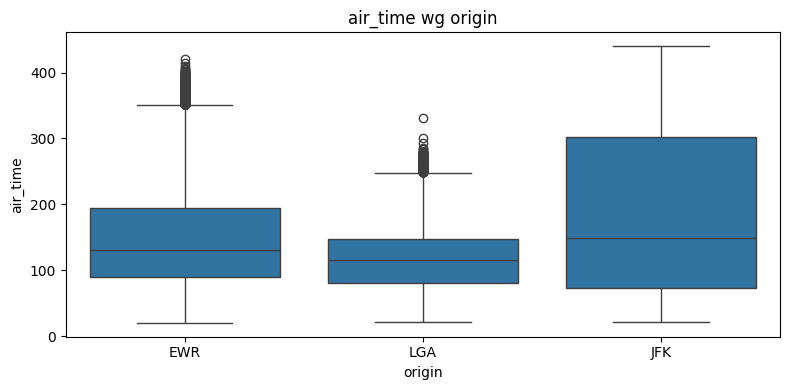

In [63]:
# Importujemy moduł `pyplot` do budowy wykresów.
import matplotlib.pyplot as plt
# Importujemy bibliotekę seaborn do estetycznych wizualizacji.
import seaborn as sns

# Tworzymy tabelę `plot_demo` po usunięciu rekordów z brakami w wybranych kolumnach.
plot_demo = flights.dropna(subset=["distance", "air_time", "carrier", "origin"]).copy()

# Zapisujemy wynik bieżącej operacji do zmiennej `plot_demo`.
plot_demo = plot_demo.query("distance <= 3000 and air_time <= 450")

# Tworzymy nowe płótno wykresu z podanym rozmiarem.
plt.figure(figsize=(8, 4))

# Rysujemy wykres rozrzutu dla wskazanych zmiennych.
sns.scatterplot(
    # Parametr `data` wskazuje tabelę, z której funkcja ma pobrać dane.
    data=plot_demo.sample(min(2000, len(plot_demo)), random_state=42),
    # Parametr `x` wskazuje zmienną odkładaną na osi poziomej.
    x="distance",
    # Parametr `y` wskazuje zmienną odkładaną na osi pionowej.
    y="air_time",
    # Parametr `alpha` steruje przezroczystością elementów na wykresie.
    alpha=0.25,
# Domykamy bieżące wyrażenie lub blok parametrów.
)
# Ustawiamy tytuł wykresu.
plt.title("distance vs air_time")
# Ustawiamy podpis osi poziomej.
plt.xlabel("distance")
# Ustawiamy podpis osi pionowej.
plt.ylabel("air_time")
# Dopasowujemy marginesy, aby elementy wykresu się nie nakładały.
plt.tight_layout()
# Wyświetlamy gotowy wykres.
plt.show()

# Tworzymy nowe płótno wykresu z podanym rozmiarem.
plt.figure(figsize=(8, 4))

# Rysujemy wykres pudełkowy porównujący rozkład między kategoriami.
sns.boxplot(data=plot_demo[plot_demo["origin"].isin(["EWR", "JFK", "LGA"])], x="origin", y="air_time")
# Ustawiamy tytuł wykresu.
plt.title("air_time wg origin")
# Ustawiamy podpis osi poziomej.
plt.xlabel("origin")
# Ustawiamy podpis osi pionowej.
plt.ylabel("air_time")
# Dopasowujemy marginesy, aby elementy wykresu się nie nakładały.
plt.tight_layout()
# Wyświetlamy gotowy wykres.
plt.show()


# <span style="color:#0f766e; font-weight:700;">3. Dane i przygotowanie środowiska</span>

W tej lekcji pracujemy na pakiecie:
- `nycflights13`

Instalacja:
- `pip install nycflights13`

Główne tabele:
- `flights`
- `airlines`
- `airports`
- `weather`
- `planes`

Źródła:
- https://pypi.org/project/nycflights13/
- https://github.com/tidyverse/nycflights13


# <span style="color:#0f766e; font-weight:700;">4. Zadania obowiązkowe (1-15)</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Wczytaj wszystkie tabele z `nycflights13` i wykonaj pełną szybką diagnostykę.

Pracuj na tabelach:
- `flights`
- `airlines`
- `airports`
- `weather`
- `planes`

Dla każdej z nich pokaż:
- `shape`
- listę kolumn przez `columns`
- pierwsze 5 rekordów przez `head()`
- strukturę przez `info()`

Najlepiej zrób to w pętli po słowniku `{'flights': flights, ...}`.

Wymagane funkcje/parametry:
- `from nycflights13 import ...` - import tabel z pakietu.
- `shape`, `columns`, `head()`, `info()` - szybka diagnostyka.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pypi.org/project/nycflights13/
- https://pandas.pydata.org/docs/reference/frame.html


In [82]:
display(flights.head(2))
display(weather.head(2))
display(airlines.head(2))
display(airports.head(2))
display(planes.head(2))


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z


,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.


,faa,name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago


,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
0,N10156,2004.0,Fixed wing multi engine,EMBRAER,EMB-145XR,2,55,NaN,Turbo-fan
1,N102UW,1998.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan


In [83]:
display(flights.shape)
display(airlines.shape)
display(airports.shape)
display(weather.shape)
display(planes.shape)

display(flights.columns)
display(airlines.columns)
display(airports.columns)
display(weather.columns)
display(planes.columns)

display(flights.info())
display(airlines.info())
display(airports.info())
display(weather.info())
display(planes.info())


(336776, 19)

(16, 2)

(1458, 8)

(26115, 15)

(3322, 9)

...

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  object 
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  object 
dtypes: float64(9), int64(4), object(2)
memory usage: 3.0+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tailnum       3322 non-null   object 
 1   year          3252 non-null   float64
 2   type          3322 non-null   object 
 3   manufacturer  3322 non-null   object 
 4   model         3322 non-null   object 
 5   engines       3322 non-null   int64  
 6   seats         3322 non-null   int64  
 7   speed         23 non-null     float64
 8   engine        3322 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 233.7+ KB


None

## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Przygotuj audyt jakości dla `flights` i `weather`.

Dla obu tabel zbuduj osobną tabelę audytu z dwiema kolumnami:
- `missing_n`
- `missing_pct`

Następnie:
- w `flights` policz duplikaty pełnych rekordów,
- w `weather` policz duplikaty po kluczu `origin`, `year`, `month`, `day`, `hour`.

Na końcu pokaż:
- `head(12)` dla tabeli braków `flights`,
- `head(12)` dla tabeli braków `weather`,
- liczbę duplikatów w obu przypadkach.

Wymagane funkcje/parametry:
- `isna().sum()` i `isna().mean()` - podsumowanie braków.
- `duplicated()` - wykrywanie duplikatów.
- `sort_values()` - ranking kolumn z największym problemem.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html


In [84]:
# tutaj dodaj swój kod isna().mean() * 100
slownik_flights = {"missing_n": [] , "missing_pct": []}
slownik_weather = {"missing_n": [] , "missing_pct": []}

slownik_flights["missing_n"] = flights.isna().sum()
slownik_flights["missing_pct"] = flights.isna().mean() * 100

slownik_weather["missing_n"] = weather.isna().sum()
slownik_weather["missing_pct"] = weather.isna().mean() * 100

df_flights = pd.DataFrame(slownik_flights)
df_weather = pd.DataFrame(slownik_weather)


display(df_flights[df_flights["missing_n"] !=0])
display(df_weather[df_weather["missing_n"] !=0])

,missing_n,missing_pct
dep_time,8255,2.451184
dep_delay,8255,2.451184
arr_time,8713,2.587180
arr_delay,9430,2.800081
tailnum,2512,0.745896
air_time,9430,2.800081


,missing_n,missing_pct
temp,1,0.003829
dewp,1,0.003829
humid,1,0.003829
wind_dir,460,1.761440
wind_speed,4,0.015317
wind_gust,20778,79.563469
pressure,2729,10.449933


## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Przygotuj roboczą tabelę `project_flights` tylko z kolumnami potrzebnymi do projektu.

Wybierz z `flights` dokładnie te kolumny:
- `year`
- `month`
- `day`
- `dep_time`
- `sched_dep_time`
- `dep_delay`
- `arr_time`
- `sched_arr_time`
- `arr_delay`
- `carrier`
- `flight`
- `tailnum`
- `origin`
- `dest`
- `air_time`
- `distance`
- `hour`
- `minute`
- `time_hour`

Zapisz wynik pod nazwą `project_flights`.

To jest zestaw potrzebny później do:
- czyszczenia braków,
- walidacji zakresów,
- budowy nowych cech,
- łączenia z pogodą, przewoźnikami i lotniskami.

Następnie pokaż 10 rekordów o największym `distance` przez `query()` lub `sort_values()`.

Wymagane funkcje/parametry:
- wybór kolumn `df[[...]]` - budowa węższej tabeli roboczej.
- `query()` albo `sort_values()` - podgląd skrajnych rekordów.
- `copy()` - bezpieczna kopia danych.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html


In [85]:
flights["distance"].head(3)

0    1400
1    1416
2    1089
Name: distance, dtype: int64

In [86]:
# tutaj dodaj swój kod
project_flights = flights[
    ["year", "month", "day", "dep_time", "sched_dep_time", "dep_delay", "arr_time", 
     "sched_arr_time", "arr_delay", "carrier", "flight", "tailnum", "origin", "dest", 
     "air_time", "distance", "hour", "minute", "time_hour"]
]

project_flights.sort_values(by="distance", ascending=False).head(10)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
209573,2013,5,18,955.0,1000,-5.0,1439.0,1500,-21.0,HA,51,N385HA,JFK,HNL,618.0,4983,10,0,2013-05-18T14:00:00Z
287901,2013,8,9,1005.0,1000,5.0,1503.0,1440,23.0,HA,51,N392HA,JFK,HNL,619.0,4983,10,0,2013-08-09T14:00:00Z
241310,2013,6,21,955.0,1000,-5.0,1432.0,1435,-3.0,HA,51,N382HA,JFK,HNL,604.0,4983,10,0,2013-06-21T14:00:00Z
197313,2013,5,5,1000.0,1000,0.0,1436.0,1500,-24.0,HA,51,N389HA,JFK,HNL,607.0,4983,10,0,2013-05-05T14:00:00Z
151311,2013,3,17,1006.0,1000,6.0,1607.0,1530,37.0,HA,51,N380HA,JFK,HNL,686.0,4983,10,0,2013-03-17T14:00:00Z
178564,2013,4,15,948.0,1000,-12.0,1458.0,1510,-12.0,HA,51,N386HA,JFK,HNL,648.0,4983,10,0,2013-04-15T14:00:00Z
20220,2013,1,24,854.0,900,-6.0,1520.0,1530,-10.0,HA,51,N389HA,JFK,HNL,657.0,4983,9,0,2013-01-24T14:00:00Z
321396,2013,9,14,955.0,1000,-5.0,1417.0,1445,-28.0,HA,51,N382HA,JFK,HNL,605.0,4983,10,0,2013-09-14T14:00:00Z
203809,2013,5,12,955.0,1000,-5.0,1428.0,1500,-32.0,HA,51,N389HA,JFK,HNL,615.0,4983,10,0,2013-05-12T14:00:00Z
166344,2013,4,2,958.0,1000,-2.0,1457.0,1510,-13.0,HA,51,N384HA,JFK,HNL,637.0,4983,10,0,2013-04-02T14:00:00Z


## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Zbuduj `flights_no_missing` przez usunięcie braków w kluczowych kolumnach.

Pracuj na `project_flights` z zadania 3.

Usuń rekordy z brakami w dokładnie tych kolumnach:
- `dep_delay`
- `arr_delay`
- `carrier`
- `dest`
- `time_hour`
- `air_time`
- `distance`

Zapisz wynik pod nazwą `flights_no_missing`.

Pokaż:
- rozmiar `project_flights`,
- rozmiar `flights_no_missing`,
- liczbę usuniętych rekordów.

Wymagane funkcje/parametry:
- `dropna(subset=[...])` - usuwanie braków w wybranych kolumnach.
- `shape` - porównanie rozmiaru tabeli przed i po czyszczeniu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html


In [87]:
# tutaj dodaj swój kod
flights_no_missing = project_flights.dropna(subset=["dep_delay","arr_delay","carrier","dest","time_hour","air_time","distance"])
display(flights_no_missing.isna().sum())
display("flights_no_missing:", flights_no_missing.shape)
display("project_flights:", project_flights.shape)


year              0
month             0
day               0
dep_time          0
sched_dep_time    0
dep_delay         0
arr_time          0
sched_arr_time    0
arr_delay         0
carrier           0
flight            0
tailnum           0
origin            0
dest              0
air_time          0
distance          0
hour              0
minute            0
time_hour         0
dtype: int64

'flights_no_missing:'

(327346, 19)

'project_flights:'

(336776, 19)

## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

Zastosuj reguły jakości zakresów i utwórz `flights_clean`.

Pracuj na `flights_no_missing` z zadania 4.

Na potrzeby tej lekcji przyjmij dokładnie następujące zakresy:
- `dep_delay` od `-60` do `360`
- `arr_delay` od `-100` do `360`
- `air_time` od `20` do `500`
- `distance` od `80` do `5000`

Traktujemy je jako robocze reguły jakości na zajęciach:
- bardzo wczesne odloty poniżej `-60` minut odrzucamy,
- skrajnie duże opóźnienia powyżej `360` minut odrzucamy,
- loty z `air_time < 20` uznajemy za problematyczne,
- dystanse poza zakresem `80-5000` traktujemy jako niespójne dla tej analizy.

Zapisz wynik pod nazwą `flights_clean`.

Pokaż:
- rozmiar `flights_no_missing`,
- rozmiar `flights_clean`,
- liczbę rekordów odrzuconych przez walidację zakresów.

Wymagane funkcje/parametry:
- `between()` - kontrola zakresów liczbowych.
- maski logiczne `&` - łączenie reguł.
- `df[mask]` - filtrowanie poprawnych rekordów.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.between.html


In [88]:
maska = (
    flights_no_missing["dep_delay"].between(-60, 360)
    & flights_no_missing["arr_delay"].between(-100, 360)
    & flights_no_missing["air_time"].between(20, 500)
    & flights_no_missing["distance"].between(80, 5000)
)

flights_clean = flights_no_missing[maska]

print("flights_no_missing:", flights_no_missing.shape)
print("flights_clean:", flights_clean.shape)
print("odrzucone rekordy:", len(flights_no_missing) - len(flights_clean))

flights_no_missing: (327346, 19)
flights_clean: (326369, 19)
odrzucone rekordy: 977


## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

Przygotuj `weather_clean` do późniejszego merge z lotami.

Pracuj na tabeli `weather`.

Wybierz dokładnie te kolumny:
- `origin`
- `year`
- `month`
- `day`
- `hour`
- `temp`
- `wind_speed`
- `precip`
- `visib`
- `pressure`
- `time_hour`

Następnie:
1. posortuj tabelę po `time_hour`,
2. usuń duplikaty po kluczu `origin`, `year`, `month`, `day`, `hour`,
3. zapisz wynik pod nazwą `weather_clean`.

Na końcu pokaż:
- rozmiar `weather_clean`,
- liczbę duplikatów po kluczu po czyszczeniu.

Wymagane funkcje/parametry:
- wybór kolumn `df[[...]]` - zawężenie danych pogodowych.
- `sort_values()` - uporządkowanie wierszy przed deduplikacją.
- `drop_duplicates(subset=[...])` - ujednoznacznienie klucza merge.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html


In [200]:
weather.duplicated().sum()

np.int64(0)

In [89]:
weather_clean = (
    weather[["origin", "year", "month", "day", "hour", "temp", "wind_speed", "precip", "visib", "pressure", "time_hour"]]
    .sort_values("time_hour")
    .drop_duplicates(subset=["origin", "year", "month", "day", "hour"]))

display(weather_clean.shape)
display(weather_clean.duplicated(subset=["origin", "year", "month", "day", "hour"]).sum())


(26112, 11)

np.int64(0)

## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Dodaj cechy analityczne i zapisz wynik jako `flights_feat`.

Pracuj na `flights_clean` z zadania 5.

Wykonaj kolejno:
1. przekonwertuj `time_hour` do typu datetime,
2. dodaj `is_delayed_dep = 1`, gdy `dep_delay > 15`, w przeciwnym razie `0`,
3. dodaj `is_delayed_arr = 1`, gdy `arr_delay > 15`, w przeciwnym razie `0`,
4. dodaj `weekday` z `time_hour`,
5. dodaj `month_num` z `time_hour`,
6. dodaj `dep_hour` z `time_hour`,
7. dodaj `delay_recovery = dep_delay - arr_delay`,
8. dodaj `dep_delay_class` przez `pd.cut()` z klasami:
   - `early`
   - `on_time`
   - `delay_16_60`
   - `delay_60_plus`

Użyj tych samych granic klas:
- `[-100, -1, 15, 60, 360]`

Zapisz wynik pod nazwą `flights_feat`.

Wymagane funkcje/parametry:
- `pd.to_datetime()` - konwersja kolumny czasu.
- `assign()` - dodanie kilku kolumn naraz.
- `.dt.day_name()` i `.dt.hour` - cechy z czasu.
- `pd.cut()` - klasy opóźnień.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html


In [90]:
flights_clean.head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z


In [91]:
flights_feat = flights_clean.copy()

flights_feat["time_hour"] = pd.to_datetime(flights_feat["time_hour"])

flights_feat["weekday"] = flights_feat["time_hour"].dt.day_name()
flights_feat["dep_hour"] = flights_feat["time_hour"].dt.hour
flights_feat["month_num"] = flights_feat["time_hour"].dt.month

flights_feat["is_delayed_dep"] = (flights_feat["dep_delay"] > 15).astype(int)
flights_feat["is_delayed_arr"] = (flights_feat["arr_delay"] > 15).astype(int)
flights_feat["delay_recovery"] = flights_feat["dep_delay"] - flights_feat["arr_delay"]

flights_feat["dep_delay_class"] = pd.cut(
    flights_feat["dep_delay"],
    bins=[-100, -1, 15, 60, 360],
    labels=["early", "on_time", "delay_16_60", "delay_60_plus"]
)

display(flights_feat.head())

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,hour,minute,time_hour,weekday,dep_hour,month_num,is_delayed_dep,is_delayed_arr,delay_recovery,dep_delay_class
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,5,15,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,0,-9.0,on_time
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,5,29,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,1,-16.0,on_time
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,5,40,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,1,-31.0,on_time
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,5,45,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,0,17.0,early
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,6,0,2013-01-01 11:00:00+00:00,Tuesday,11,1,0,0,19.0,early


## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

Połącz `flights_feat` z `airlines` i `airports`.

Pracuj tak:
1. do `flights_feat` dołącz `airlines` po kolumnie `carrier`,
2. z `airports` przygotuj lookup tylko dla lotnisk docelowych z kolumn:
   - `faa`
   - `name`
   - `lat`
   - `lon`
3. zmień nazwy tak, aby po merge mieć:
   - `dest`
   - `dest_airport_name`
   - `dest_lat`
   - `dest_lon`
4. dołącz tę tabelę do lotów po `dest`.

W obu merge:
- użyj `validate='many_to_one'`,
- dodaj `indicator`,
- końcową tabelę zapisz jako `flights_geo`.

Na końcu pokaż:
- `value_counts()` dla statusu merge z `airlines`,
- `value_counts()` dla statusu merge z `airports`,
- kilka pierwszych wierszy z nowymi kolumnami.

Wymagane funkcje/parametry:
- `merge()` - łączenie tabel.
- `rename(columns={...})` - czytelne nazwy po merge z airports.
- `validate='many_to_one'` i `indicator` - kontrola merge.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html


In [92]:
display(airports.head(3))
display(flights_feat.head(8))
display(airlines.head(8))

,faa,name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago
2,06C,Schaumburg Regional,41.989341,-88.101243,801,-6,A,America/Chicago


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,hour,minute,time_hour,weekday,dep_hour,month_num,is_delayed_dep,is_delayed_arr,delay_recovery,dep_delay_class
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,5,15,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,0,-9.0,on_time
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,5,29,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,1,-16.0,on_time
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,5,40,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,1,-31.0,on_time
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,5,45,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,0,17.0,early
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,6,0,2013-01-01 11:00:00+00:00,Tuesday,11,1,0,0,19.0,early
5,2013,1,1,554.0,558,-4.0,740.0,728,12.0,UA,...,5,58,2013-01-01 10:00:00+00:00,Tuesday,10,1,0,0,-16.0,early
6,2013,1,1,555.0,600,-5.0,913.0,854,19.0,B6,...,6,0,2013-01-01 11:00:00+00:00,Tuesday,11,1,0,1,-24.0,early
7,2013,1,1,557.0,600,-3.0,709.0,723,-14.0,EV,...,6,0,2013-01-01 11:00:00+00:00,Tuesday,11,1,0,0,11.0,early


,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation


In [93]:
# tutaj dodaj swój kod
airports_dest = airports[["faa", "name", "lat", "lon"]].rename(
    columns={
        "faa": "dest",
        "name": "dest_airport_name",
        "lat": "dest_lat",
        "lon": "dest_lon",})

flights_geo = flights_feat.merge(
    airlines,
    on="carrier",
    how="left",
    validate="many_to_one",
    indicator="kontrola_merge_airlines")

flights_geo = flights_geo.merge(
    airports_dest,
    on="dest",
    how="left",
    validate="many_to_one",
    indicator="kontrola_merge_airports")

print(flights_geo["kontrola_merge_airlines"].value_counts())
print(flights_geo["kontrola_merge_airports"].value_counts())

display(flights_geo[["carrier", "name", "dest", "dest_airport_name", "dest_lat", "dest_lon"]].head())

kontrola_merge_airlines
both          326369
left_only          0
right_only         0
Name: count, dtype: int64
kontrola_merge_airports
both          318834
left_only       7535
right_only         0
Name: count, dtype: int64


,carrier,name,dest,dest_airport_name,dest_lat,dest_lon
0,UA,United Air Lines Inc.,IAH,George Bush Intercontinental,29.984433,-95.341442
1,UA,United Air Lines Inc.,IAH,George Bush Intercontinental,29.984433,-95.341442
2,AA,American Airlines Inc.,MIA,Miami Intl,25.793250,-80.290556
3,B6,JetBlue Airways,BQN,NaN,NaN,NaN
4,DL,Delta Air Lines Inc.,ATL,Hartsfield Jackson Atlanta Intl,33.636719,-84.428067


## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Połącz `flights_geo` z `weather_clean` i utwórz `analysis_df`.

Pracuj na:
- `flights_geo` z zadania 8,
- `weather_clean` z zadania 6.

Dołącz pogodę po wspólnym kluczu:
- `origin`
- `year`
- `month`
- `day`
- `hour`

Po merge:
- użyj `validate='many_to_one'`,
- dodaj `indicator='merge_weather'`,
- zapisz wynik pod nazwą `analysis_df`.

Na końcu pokaż:
- `value_counts()` dla `merge_weather`,
- `value_counts(normalize=True)` dla `merge_weather`,
- kilka pierwszych wierszy z kolumnami pogodowymi.

Wymagane funkcje/parametry:
- `merge()` - połączenie z tabelą pogodową.
- `validate='many_to_one'` - kontrola relacji klucza.
- `indicator` i `value_counts(normalize=True)` - audyt dopasowania.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html


In [100]:
display(flights_geo[["origin", 'year', 'month','day', 'hour']].head(3))
display(flights_geo.columns)
display(weather_clean.head(3))

,origin,year,month,day,hour
0,EWR,2013,1,1,5
1,LGA,2013,1,1,5
2,JFK,2013,1,1,5


Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour', 'weekday', 'dep_hour', 'month_num', 'is_delayed_dep',
       'is_delayed_arr', 'delay_recovery', 'dep_delay_class', 'name',
       'kontrola_merge_airlines', 'dest_airport_name', 'dest_lat', 'dest_lon',
       'kontrola_merge_airports'],
      dtype='object')

,origin,year,month,day,hour,temp,wind_speed,precip,visib,pressure,time_hour
0,EWR,2013,1,1,1,39.02,10.35702,0.0,10.0,1012.0,2013-01-01T06:00:00Z
8703,JFK,2013,1,1,1,39.02,12.65858,0.0,10.0,1012.6,2013-01-01T06:00:00Z
17409,LGA,2013,1,1,1,39.92,13.80936,0.0,10.0,1011.9,2013-01-01T06:00:00Z


In [101]:
# tutaj dodaj swój kod
analysis_df = flights_geo.merge(
    weather_clean,
    on = ["origin", 'year', 'month','day', 'hour'],
    how="left",
    validate="many_to_one",
    indicator="merge_weather"

)

In [106]:
print(analysis_df["merge_weather"].value_counts())
display(analysis_df["merge_weather"].head(3))
print(analysis_df["merge_weather"].value_counts(normalize=True))

merge_weather
both          324845
left_only       1524
right_only         0
Name: count, dtype: int64


0    both
1    both
2    both
Name: merge_weather, dtype: category
Categories (3, object): ['left_only', 'right_only', 'both']

merge_weather
both          0.99533
left_only     0.00467
right_only    0.00000
Name: proportion, dtype: float64


## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Q1: Zrób ranking przewoźników po medianie `dep_delay`.

Pracuj na `analysis_df`.

Pogrupuj dane po:
- `carrier`
- `name`

Policz dokładnie te kolumny wynikowe:
- `flights_n`
- `dep_delay_mean`
- `dep_delay_median`
- `on_time_rate`
- `delay_recovery_mean`

Przyjmij:
- `on_time_rate = 1 - mean(is_delayed_dep)`

Zostaw tylko przewoźników z minimum `1000` lotów, posortuj rosnąco po `dep_delay_median` i pokaż najlepszych 15.

Wymagane funkcje/parametry:
- `groupby().agg()` - agregacja po przewoźniku.
- `query()` - filtr minimalnej liczebności.
- `sort_values()` - ranking wyników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html


In [132]:
analysis_df.columns

display(flights.columns)
display(weather.columns)
display(airlines.columns)
display(airports.columns)
display(planes.columns)
display(analysis_df.columns)

# nie ma kolumny on_time 

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='object')

Index(['origin', 'year', 'month', 'day', 'hour', 'temp', 'dewp', 'humid',
       'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib',
       'time_hour'],
      dtype='object')

Index(['carrier', 'name'], dtype='object')

Index(['faa', 'name', 'lat', 'lon', 'alt', 'tz', 'dst', 'tzone'], dtype='object')

Index(['tailnum', 'year', 'type', 'manufacturer', 'model', 'engines', 'seats',
       'speed', 'engine'],
      dtype='object')

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour_x', 'weekday', 'dep_hour', 'month_num', 'is_delayed_dep',
       'is_delayed_arr', 'delay_recovery', 'dep_delay_class', 'name',
       'kontrola_merge_airlines', 'dest_airport_name', 'dest_lat', 'dest_lon',
       'kontrola_merge_airports', 'temp', 'wind_speed', 'precip', 'visib',
       'pressure', 'time_hour_y', 'merge_weather'],
      dtype='object')

In [141]:
analysis_df[["flight", "dep_delay", "delay_recovery"]]

,flight,dep_delay,delay_recovery
0,1545,2.0,-9.0
1,1714,4.0,-16.0
2,1141,2.0,-31.0
3,725,-1.0,17.0
4,461,-6.0,19.0
...,...,...,...
326364,1816,-5.0,12.0
326365,2002,-10.0,10.0
326366,486,-5.0,11.0
326367,718,12.0,11.0


In [184]:
# tutaj dodaj swój kod
q1_q1 = analysis_df.groupby(["carrier","name"]).agg(
    flights_n=("flight", "count"),
    dep_delay_mean=("dep_delay", "mean"),
    on_time_rate=("is_delayed_dep", lambda x: 1 - x.mean()),
    dep_delay_median=("dep_delay", "median"),
    delay_recovery_mean=("delay_recovery", "mean")).query("flights_n > 1000").sort_values(by="dep_delay_median", ascending=True).head(15)

q1_q1

,,flights_n,dep_delay_mean,on_time_rate,dep_delay_median,delay_recovery_mean
carrier,name,,,,,
US,US Airways Inc.,19826,3.637849,0.878695,-4.0,1.614395
AA,American Airlines Inc.,31919,8.095116,0.841818,-3.0,8.206021
MQ,Envoy Air,25023,10.112217,0.789993,-3.0,-0.325021
DL,Delta Air Lines Inc.,47584,8.442838,0.838538,-2.0,7.587529
9E,Endeavor Air Inc.,17285,16.228522,0.745502,-2.0,9.071449
B6,JetBlue Airways,54020,12.769197,0.772732,-1.0,3.513569
EV,ExpressJet Airlines Inc.,51068,19.540945,0.697031,-1.0,4.054711
UA,United Air Lines Inc.,57383,11.751965,0.790983,0.0,8.463256
VX,Virgin America,5107,11.980223,0.827687,0.0,11.011944


## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Q2: Wyznacz TOP 10 kierunków z najwyższym średnim `arr_delay`.

Pracuj na `analysis_df`.

Pogrupuj dane po:
- `dest`
- `dest_airport_name`

Policz dokładnie te kolumny wynikowe:
- `flights_n`
- `arr_delay_mean`
- `arr_delay_median`
- `distance_mean`
- `air_time_mean`

Zostaw tylko kierunki z minimum `500` lotów, posortuj malejąco po `arr_delay_mean` i pokaż TOP 10.

Wymagane funkcje/parametry:
- `groupby().agg()` - agregacja po kierunku.
- `query()` - filtr minimalnej liczebności.
- `head(10)` - ranking końcowy.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html


In [187]:
analysis_df.head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,dest_lat,dest_lon,kontrola_merge_airports,temp,wind_speed,precip,visib,pressure,time_hour_y,merge_weather
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,29.984433,-95.341442,both,39.02,12.65858,0.0,10.0,1011.9,2013-01-01T10:00:00Z,both
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,29.984433,-95.341442,both,39.92,14.96014,0.0,10.0,1011.4,2013-01-01T10:00:00Z,both
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,25.793250,-80.290556,both,39.02,14.96014,0.0,10.0,1012.1,2013-01-01T10:00:00Z,both


In [189]:
# tutaj dodaj swój kod

# tutaj dodaj swój kod
q2_q2 = analysis_df.groupby(["dest_airport_name","dest"]).agg(
    flights_n=("flight", "count"),
    arr_delay_mean=("arr_delay", "mean"),
    arr_delay_median=("arr_delay", "median"),
    distance_mean=("distance", "mean"),
    air_time_mean=("air_time", "mean")).query("flights_n > 500").sort_values(by="arr_delay_mean", ascending=False).head(10)

q2_q2


,,flights_n,arr_delay_mean,arr_delay_median,distance_mean,air_time_mean
dest_airport_name,dest,,,,,
Mc Ghee Tyson,TYS,578,24.069204,2.0,638.335640,97.719723
Richmond Intl,RIC,2343,19.610329,1.0,281.272300,53.995732
Dane Co Rgnl Truax Fld,MSN,555,19.576577,1.0,803.918919,122.814414
Des Moines Intl,DSM,523,19.005736,0.0,1020.560229,148.678776
Akron Canton Regional Airport,CAK,839,18.305125,2.0,397.000000,64.016687
Gerald R Ford Intl,GRR,728,18.189560,1.0,605.714286,97.000000
Greenville-Spartanburg International,GSP,790,15.935443,-0.5,595.984810,93.394937
Cincinnati Northern Kentucky Intl,CVG,3722,14.877754,-3.0,575.218162,95.965073
Manchester Regional Airport,MHT,932,14.787554,-3.0,207.377682,38.508584


## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Q3: Oceń relację między opóźnieniami a pogodą.

Pracuj na `analysis_df`.

Wykonaj dwa kroki:
1. Zbuduj podzbiór bez braków dla kolumn:
   - `dep_delay`
   - `temp`
   - `wind_speed`
   - `precip`
   - `visib`
   - `pressure`
2. Na tym podzbiorze:
   - policz korelacje,
   - podziel `pressure` na 4 przedziały przez `pd.qcut()` albo `pd.cut()`,
   - policz w tych grupach:
     - `flights_n`
     - `dep_delay_mean`
     - `dep_delay_median`

Zapisz tabelę korelacji jako `q3_corr`, a tabelę pasm ciśnienia jako `q3_pressure_groups`.

Wymagane funkcje/parametry:
- `corr()` - korelacje zmiennych liczbowych.
- `pd.qcut()` albo `pd.cut()` - przedziały ciśnienia.
- `groupby().agg()` - podsumowanie grup pogodowych.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


In [161]:
display(analysis_df["pressure"])
display(maska.isna().sum())

0         1011.9
1         1011.4
2         1012.1
3         1012.1
4         1011.7
           ...  
326364    1016.5
326365    1016.5
326366    1016.5
326367    1016.5
326368    1016.3
Name: pressure, Length: 326369, dtype: float64

flight          0
dep_delay       0
temp            0
wind_speed      0
precip          0
visib           0
pressure        0
pressure_bin    0
dtype: int64

In [164]:
# tutaj dodaj swój kod
q3_pressure_groups = analysis_df[["flight", "dep_delay","temp","wind_speed","precip","visib","pressure"]]
q3_corr=analysis_df[["flight", "dep_delay","temp","wind_speed","precip","visib","pressure"]].corr()

q3_pressure_groups["pressure_bin"] = pd.cut(q3_pressure_groups["pressure"], bins=4)

display()

display(q3_pressure_groups.head())

q3_pressure_groups.groupby(["pressure_bin"]).agg(flights_n = ("flight", "count"), dep_delay_mean = ("dep_delay", "mean" ), dep_delay_median = ("dep_delay","median"))



/tmp/ipykernel_18989/2641506414.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q3_pressure_groups["pressure_bin"] = pd.cut(q3_pressure_groups["pressure"], bins=4)


,flight,dep_delay,temp,wind_speed,precip,visib,pressure,pressure_bin
0,1545,2.0,39.02,12.65858,0.0,10.0,1011.9,"(998.375, 1012.95]"
1,1714,4.0,39.92,14.96014,0.0,10.0,1011.4,"(998.375, 1012.95]"
2,1141,2.0,39.02,14.96014,0.0,10.0,1012.1,"(998.375, 1012.95]"
3,725,-1.0,39.02,14.96014,0.0,10.0,1012.1,"(998.375, 1012.95]"
4,461,-6.0,39.92,16.11092,0.0,10.0,1011.7,"(998.375, 1012.95]"


/tmp/ipykernel_18989/2641506414.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q3_pressure_groups.groupby(["pressure_bin"]).agg(flights_n = ("flight", "count"), dep_delay_mean = ("dep_delay", "mean" ), dep_delay_median = ("dep_delay","median"))


,flights_n,dep_delay_mean,dep_delay_median
pressure_bin,,,
"(983.742, 998.375]",860,29.997674,4.0
"(998.375, 1012.95]",72630,16.745463,-1.0
"(1012.95, 1027.525]",188057,9.145318,-2.0
"(1027.525, 1042.1]",28838,5.545218,-3.0


## <span style="color:#0f766e; font-weight:700;">Zadanie 13</span>

Q4: Sprawdź punktualność w czasie.

Pracuj na `analysis_df`.

Przygotuj trzy wyniki:
1. `q4_month` przez grupowanie po `month_num`
2. `q4_weekday` przez grupowanie po `weekday`
3. `q4_hour_pivot` jako tabelę `weekday x dep_hour`

W `q4_month` i `q4_weekday` policz:
- `flights_n`
- `on_time_rate`
- `dep_delay_median`

Przyjmij:
- `on_time_rate = 1 - mean(is_delayed_dep)`

W `q4_hour_pivot` użyj:
- `index='weekday'`
- `columns='dep_hour'`
- `values='is_delayed_dep'`
- `aggfunc='mean'`

Wymagane funkcje/parametry:
- `groupby().agg()` - podsumowania miesięczne i tygodniowe.
- `pivot_table()` - tabela do dalszej heatmapy.
- `sort_index()` albo `sort_values()` - uporządkowanie wyników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html


In [165]:
analysis_df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour_x', 'weekday', 'dep_hour', 'month_num', 'is_delayed_dep',
       'is_delayed_arr', 'delay_recovery', 'dep_delay_class', 'name',
       'kontrola_merge_airlines', 'dest_airport_name', 'dest_lat', 'dest_lon',
       'kontrola_merge_airports', 'temp', 'wind_speed', 'precip', 'visib',
       'pressure', 'time_hour_y', 'merge_weather'],
      dtype='object')

In [168]:
# tutaj dodaj swój kod
q4_month=analysis_df.groupby("month_num").agg(flights_n = ("flight","count"), 
     on_time_rate=("is_delayed_dep", lambda x: 1 - x.mean()), 
     dep_delay_median = ("dep_delay","median"))

q4_weekday=analysis_df.groupby("weekday").agg(flights_n = ("flight","count"), 
     on_time_rate=("is_delayed_dep", lambda x: 1 - x.mean()), 
     dep_delay_median = ("dep_delay","median"))

q4_hour_pivot=analysis_df.pivot_table(index="weekday", 
                                      columns="dep_hour", values="is_delayed_dep", aggfunc="mean")

display(q4_month)
display(q4_weekday)
display(q4_hour_pivot)

,flights_n,on_time_rate,dep_delay_median
month_num,,,
1,26278,0.817147,-2.0
2,23523,0.796327,-2.0
3,27867,0.778627,-1.0
4,27505,0.775095,-2.0
5,28038,0.772880,-1.0
6,26966,0.715939,0.0
7,28158,0.704524,0.0
8,28733,0.779731,-1.0
9,26891,0.862147,-3.0


,flights_n,on_time_rate,dep_delay_median
weekday,,,
Friday,48319,0.756680,-1.0
Monday,49243,0.767134,-1.0
Saturday,39942,0.808472,-2.0
Sunday,42915,0.819014,-2.0
Thursday,48206,0.761150,-1.0
Tuesday,49211,0.794538,-2.0
Wednesday,48533,0.801228,-2.0


dep_hour,0,1,2,3,4,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,
Friday,0.424219,0.435676,0.368020,0.303571,0.188679,0.041451,0.071040,0.093732,0.116050,0.135436,0.151539,0.184065,0.197127,0.238948,0.257667,0.297912,0.307347,0.341365,0.333651,0.367060
Monday,0.366630,0.383470,0.405048,0.403587,0.264151,0.045455,0.074442,0.086533,0.103882,0.129663,0.160646,0.159475,0.184200,0.222461,0.254630,0.301813,0.305749,0.324439,0.326195,0.350159
Saturday,0.397048,0.410367,0.347938,0.278302,0.203704,0.076923,0.081146,0.090134,0.103583,0.116129,0.136558,0.149137,0.137845,0.164024,0.175130,0.202280,0.212230,0.212735,0.211886,0.244424
Sunday,0.242763,0.203291,0.208092,0.244131,0.153846,0.069930,0.064980,0.067275,0.071997,0.096211,0.113686,0.105312,0.128927,0.143906,0.173405,0.224785,0.247036,0.279536,0.296157,0.331751
Thursday,0.325067,0.353071,0.306069,0.300469,0.037736,0.056995,0.065804,0.074146,0.104565,0.121157,0.144676,0.159352,0.202951,0.263546,0.285519,0.318410,0.338160,0.363427,0.354788,0.391051
Tuesday,0.355258,0.365263,0.290168,0.355556,0.200000,0.036269,0.067607,0.066409,0.101818,0.113897,0.127161,0.158879,0.173930,0.199927,0.225426,0.245803,0.271927,0.279350,0.284438,0.297502
Wednesday,0.308214,0.314712,0.312418,0.268722,0.145455,0.052632,0.061489,0.069441,0.089540,0.113260,0.122114,0.129771,0.169358,0.205138,0.216767,0.245393,0.261187,0.282386,0.294612,0.317531


## <span style="color:#0f766e; font-weight:700;">Zadanie 14</span>

Przygotuj dwa przekrojowe podsumowania: `pivot_table()` i `crosstab()`.

Pracuj na `analysis_df`.

Zrób dokładnie:
1. `q14_pivot` ze średnim `dep_delay` w układzie:
   - wiersze: `origin`
   - kolumny: `carrier`
   - wartości: `dep_delay`
2. `q14_crosstab` z udziałem klas `dep_delay_class`:
   - wiersze: `origin`
   - kolumny: `dep_delay_class`
   - normalizacja: `normalize='index'`

Na końcu pokaż obie tabele.

Wymagane funkcje/parametry:
- `pivot_table()` - tabela przestawna z agregacją.
- `pd.crosstab(..., normalize='index')` - udział klas w wierszach.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html
- https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html


In [171]:
# tutaj dodaj swój kod
q14_pivot = analysis_df.pivot_table(index="origin", columns="carrier", values="dep_delay", aggfunc="mean")
q14_crosstab = pd.crosstab(index=analysis_df["origin"], columns=analysis_df["dep_delay_class"], normalize="index")


display(q14_pivot)
display(q14_crosstab)

carrier,9E,AA,AS,B6,DL,EV,F9,FL,MQ,OO,UA,US,VX,WN,YV
origin,,,,,,,,,,,,,,,
EWR,5.656329,8.876043,5.830748,12.540377,10.497315,19.814307,NaN,NaN,15.516746,20.833333,12.244681,3.503700,11.529336,17.518261,NaN
JFK,18.438506,9.853642,NaN,12.569820,7.759482,16.962150,NaN,NaN,12.463554,NaN,7.660858,5.741141,12.176884,NaN,NaN
LGA,8.709623,6.323983,NaN,14.425669,8.672876,18.573759,18.371134,16.876028,8.412956,10.434783,11.248619,3.187096,NaN,17.070222,18.220994


dep_delay_class,early,on_time,delay_16_60,delay_60_plus
origin,,,,
EWR,0.505837,0.249447,0.152942,0.091774
JFK,0.559231,0.234502,0.130444,0.075824
LGA,0.623234,0.189229,0.117528,0.070008


## <span style="color:#0f766e; font-weight:700;">Zadanie 15</span>

Q5: Zbuduj końcowy audyt i mini-raport projektu.

Pracuj na wynikach z poprzednich zadań.

Twoja odpowiedź ma mieć 3 części:

1. Tabela audytu
   Zbuduj tabelę z krokami:
   - `flights raw`
   - `flights after_dropna`
   - `flights after_range_validation`
   - `weather raw`
   - `weather after_dedupe`
   - `analysis final_after_merges`

   Dla każdego kroku pokaż:
   - `dataset`
   - `step`
   - `rows`
   - `removed_vs_prev`

2. Trzy wykresy
   Zrób dokładnie trzy wykresy:
   - ranking przewoźników z Q1,
   - ranking kierunków z Q2,
   - `on_time_rate` wg miesiąca z Q4.

3. Krótkie wnioski tekstowe
   Napisz po 1 krótkiej odpowiedzi do:
   - Q1
   - Q2
   - Q3
   - Q4
   - Q5

Wymagane funkcje/parametry:
- `pd.DataFrame()` - tabela audytu.
- `matplotlib` i `seaborn` - trzy wykresy.
- krótkie wnioski tekstowe oparte na wcześniej policzonych wynikach.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://matplotlib.org/stable/api/pyplot_summary.html
- https://seaborn.pydata.org/


In [179]:
display(flights.isna().sum())

year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

In [ ]:
flights.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='object')

In [206]:
# W zadaniu 5 robimy walidacje po czyszczeniu a punkt 3 wskazuje raczej na wykonanie walidacji zakresu bezposrednio na danych z flights co robie ponizej uzywajac logiki z zadania 5

maska_flights = (
    flights["dep_delay"].between(-60, 360)
    & flights["arr_delay"].between(-100, 360)
    & flights["air_time"].between(20, 500)
    & flights["distance"].between(80, 5000)
)

flights_clean_with_NaN = flights[maska_flights]

display(len(flights_clean_with_NaN))
display(len(flights_clean))

#wniosek: uzywajac maski autoamtycznie odrzuca nam wiersze z wartosciami NaN 

326369

326369

In [207]:
audit = pd.DataFrame([
    {"dataset":"flights", "step":"flights_raw", "rows":len(flights), "removed_vs_prev":0},

    {"dataset":"flights", "step":"flights_after_dropna", "rows":len(flights), "removed_vs_prev":len(project_flights)-len(flights_no_missing)},

    {"dataset":"flights", "step":"flights_after_range_validation", "rows":len(flights), "removed_vs_prev":len(flights)-len(flights_clean_with_NaN)},

    {"dataset":"weather", "step":"weather_raw", "rows":len(weather), "removed_vs_prev":0},

    {"dataset":"weather", "step":"weather_after_dedupe", "rows":len(weather_clean), "removed_vs_prev":len(weather)-len(weather_clean)},
    
    {"dataset":"analysis", "step":"analysis_final_after_merges", "rows":len(analysis_df), "removed_vs_prev":0},
])

display(audit)

,dataset,step,rows,removed_vs_prev
0,flights,flights_raw,336776,0
1,flights,flights_after_dropna,336776,9430
2,flights,flights_after_range_validation,336776,10407
3,weather,weather_raw,26115,0
4,weather,weather_after_dedupe,26112,3
5,analysis,analysis_final_after_merges,326369,0


Text(0.5, 1.0, 'Ranking przewoźników z Q1')

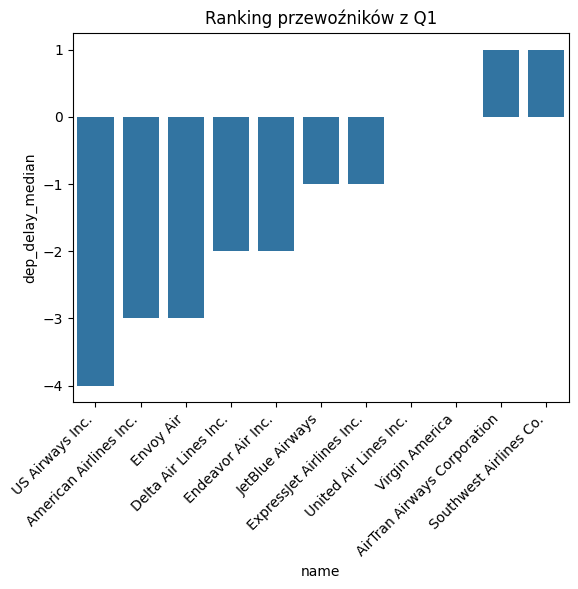

In [219]:
sns.barplot(data=q1_q1, x="name", y="dep_delay_median")
plt.xticks(rotation=45, ha="right")
plt.title("Ranking przewoźników z Q1")

Text(0.5, 1.0, 'Ranking kierunków z Q2')

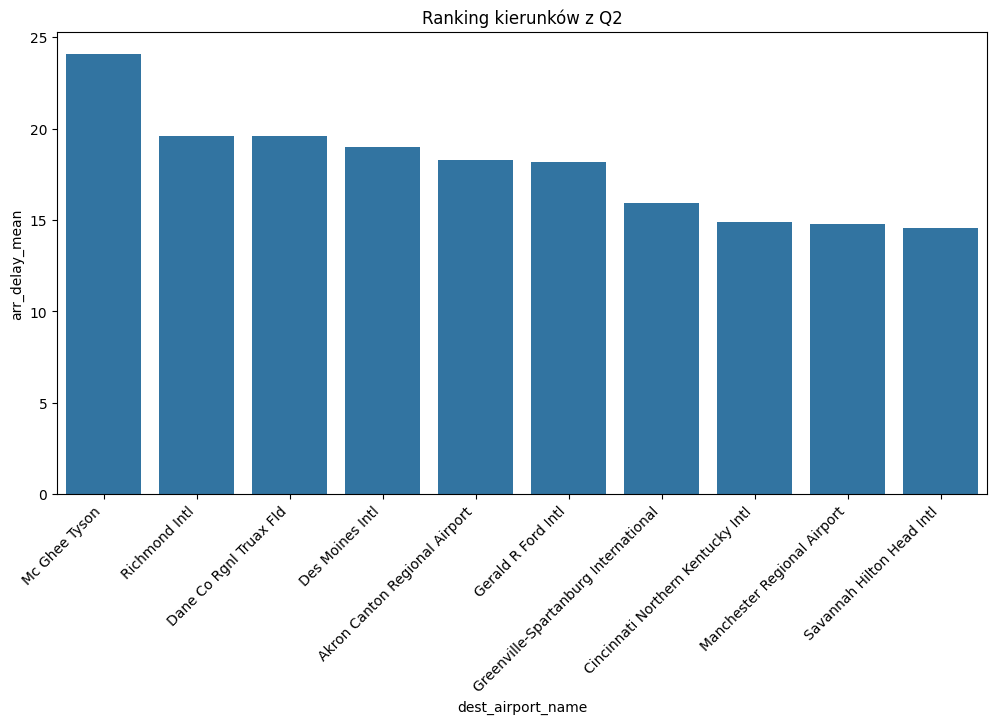

In [218]:
plt.figure(figsize=(12, 6))
sns.barplot(data=q2_q2, x="dest_airport_name", y="arr_delay_mean")
plt.xticks(rotation=45, ha="right")
plt.title("Ranking kierunków z Q2")

Text(0.5, 1.0, 'Q4: On-time rate wg miesiąca')

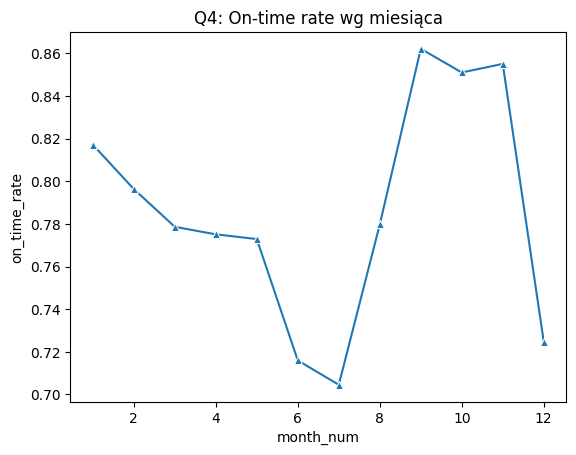

In [217]:
sns.lineplot(data=q4_month.reset_index(), x="month_num", y="on_time_rate", marker="^")
plt.title("Q4: On-time rate wg miesiąca")

In [222]:

print("Q1: Najniższe typowe opóźnienia odlotu przy dużej liczbie lotów ma głównie US Airways. Dobrze wypada też American Airlines i Envoy Air.")
print("Q2: Najwyższe średnie opóźnienia przylotu pojawiają się m.in. na kierunkach TYS i RIC.")
print("Q3: Widać związek pogody z opóźnieniami – przy gorszych warunkach (np. niższym ciśnieniu) opóźnienia są zwykle większe.")
print("Q4: Punktualność zmienia się w czasie – gorzej jest w wakacje i pod koniec roku oraz w późniejszych godzinach dnia.")
print("Q5: Odrzucono ok. 10,4 tys. rekordów lotów przez braki danych i walidację zakresów oraz 3 rekordy pogody przez duplikaty.")


Q1: Najniższe typowe opóźnienia odlotu przy dużej liczbie lotów ma głównie US Airways. Dobrze wypada też American Airlines i Envoy Air.
Q2: Najwyższe średnie opóźnienia przylotu pojawiają się m.in. na kierunkach TYS i RIC.
Q3: Widać związek pogody z opóźnieniami – przy gorszych warunkach (np. niższym ciśnieniu) opóźnienia są zwykle większe.
Q4: Punktualność zmienia się w czasie – gorzej jest w wakacje i pod koniec roku oraz w późniejszych godzinach dnia.
Q5: Odrzucono ok. 10,4 tys. rekordów lotów przez braki danych i walidację zakresów oraz 3 rekordy pogody przez duplikaty.


# <span style="color:#0f766e; font-weight:700;">5. Zadania dodatkowe (16-24)</span>


## <span style="color:#0f766e; font-weight:700;">Zadanie 16 - dodatkowe</span>

Zbuduj heatmapę `weekday x dep_hour` dla `on_time_rate`.

Pracuj na `q4_hour_pivot` z zadania 13.

Pokaż heatmapę, w której:
- wiersze to `weekday`,
- kolumny to `dep_hour`,
- kolor pokazuje `on_time_rate`.

Jeśli Twoja tabela zawiera średnią z `is_delayed_dep`, pamiętaj, że:
- `on_time_rate = 1 - mean(is_delayed_dep)`.

Wymagane funkcje/parametry:
- `pivot_table()` - tabela wejściowa do heatmapy.
- `sns.heatmap()` - wizualizacja punktualności.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.heatmap.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 17 - dodatkowe</span>

Przeanalizuj anulowane loty.

Pracuj na surowej tabeli `flights`.

Przyjmij definicję:
- lot anulowany = rekord z brakującym `dep_time`

Przygotuj dwa wyniki:
1. `cancel_by_month` z kolumnami:
   - `flights_n`
   - `cancel_rate`
2. `cancel_by_carrier` z kolumnami:
   - `flights_n`
   - `cancel_rate`

Dla przewoźników pokaż TOP 10 po najwyższym `cancel_rate`.

Wymagane funkcje/parametry:
- `isna()` - identyfikacja anulowanych lotów przez brak `dep_time`.
- `groupby().agg()` - agregacja po miesiącu i przewoźniku.
- `sort_values()` - ranking przewoźników.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.Series.isna.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 18 - dodatkowe</span>

Dołącz `planes` i oceń wpływ wieku samolotu na `arr_delay`.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. z `planes` wybierz kolumny:
   - `tailnum`
   - `year`
   - `manufacturer`
   - `model`
   - `seats`
2. zmień nazwę `year` na `plane_year`,
3. skonwertuj `plane_year` do typu liczbowego,
4. połącz dane z `analysis_df` po `tailnum`,
5. policz `plane_age = year - plane_year`,
6. zbuduj `plane_age_bin` przez `pd.cut()` z przedziałami:
   - `[0, 5, 10, 20, 40, 80]`
7. policz w tych grupach:
   - `flights_n`
   - `arr_delay_mean`

Wymagane funkcje/parametry:
- `merge()` - łączenie z tabelą planes.
- `pd.to_numeric()` - konwersja roku produkcji samolotu.
- `pd.cut()` - grupowanie wieku samolotu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
- https://pandas.pydata.org/docs/reference/api/pandas.cut.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 19 - dodatkowe</span>

Znajdź najbardziej niestabilne trasy.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. utwórz `route = origin + '-' + dest`,
2. pogrupuj po `route`,
3. policz:
   - `flights_n`
   - `arr_delay_std`
   - `arr_delay_mean`
4. zostaw tylko trasy z minimum `200` lotów,
5. posortuj malejąco po `arr_delay_std`,
6. pokaż TOP 15.

Wymagane funkcje/parametry:
- `assign()` - utworzenie zmiennej `route`.
- `groupby().agg()` - liczebność i zmienność opóźnień.
- `query()` i `sort_values()` - ranking tras.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 20 - dodatkowe</span>

Porównaj średnią, medianę i średnią obciętą `dep_delay` dla przewoźników.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. napisz własną funkcję `trimmed_mean()`,
2. dla każdego `carrier` policz:
   - `flights_n`
   - `dep_delay_mean`
   - `dep_delay_median`
   - `dep_delay_trimmed`
3. zostaw tylko przewoźników z minimum `1000` lotów,
4. posortuj wynik po `dep_delay_median`.

Jeśli chcesz, możesz przyjąć obcięcie 10% obserwacji z obu stron rozkładu.

Wymagane funkcje/parametry:
- własna funkcja `trimmed_mean()` - średnia obcięta.
- `groupby().agg()` - zestaw kilku miar naraz.
- `query()` i `sort_values()` - końcowa tabela rankingowa.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://docs.python.org/3/tutorial/controlflow.html#defining-functions


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 21 - dodatkowe</span>

Policz bootstrapowy 95% CI dla mediany `dep_delay` dla dwóch przewoźników.

Pracuj na `analysis_df`.

Wybierz dwóch największych przewoźników według liczby lotów. Następnie dla każdego z nich:
1. pobierz wektor `dep_delay`,
2. wykonaj bootstrap z losowaniem ze zwracaniem,
3. policz 1000 bootstrapowych median,
4. wyznacz:
   - medianę z danych,
   - `ci95_low`,
   - `ci95_high`

Końcowy wynik pokaż w tabeli z kolumnami:
- `carrier`
- `median_dep_delay`
- `ci95_low`
- `ci95_high`

Wymagane funkcje/parametry:
- `np.random.default_rng()` - losowanie bootstrapowe.
- `np.percentile()` - przedział ufności z rozkładu bootstrapowego.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.percentile.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 22 - dodatkowe</span>

Zbuduj prosty baseline `arr_delay ~ dep_delay + distance`.

Pracuj na `analysis_df`.

Wykonaj kolejno:
1. zbuduj podzbiór bez braków dla:
   - `arr_delay`
   - `dep_delay`
   - `distance`
2. policz macierz korelacji,
3. dopasuj prostą `arr_delay ~ dep_delay` przez `np.polyfit()`,
4. wypisz:
   - macierz korelacji,
   - `slope`,
   - `intercept`

Nie budujesz tu modelu ML, tylko bardzo prosty baseline opisowy.

Wymagane funkcje/parametry:
- `corr()` - korelacje między zmiennymi.
- `np.polyfit()` - prosta linia trendu.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 23 - dodatkowe</span>

Wyeksportuj oczyszczoną tabelę i kluczowe wyniki.

Pracuj na:
- `analysis_df`
- `q1_carriers`
- `q2_destinations`

Wykonaj kolejno:
1. utwórz folder `dane_lekcja4_wyniki`,
2. zapisz do CSV:
   - `analysis_df`
   - `q1_carriers`
   - `q2_destinations`
3. przygotuj krótki słownik z metrykami:
   - `rows_final`
   - najlepszy przewoźnik
   - najgorszy kierunek
4. zapisz ten słownik do JSON.

Wymagane funkcje/parametry:
- `to_csv(index=False)` - eksport tabel do CSV.
- `json.dump(..., indent=2)` - eksport krótkiego raportu do JSON.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html
- https://docs.python.org/3/library/json.html


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 24 - dodatkowe</span>

Napisz funkcję `run_lesson4_pipeline()` zwracającą słownik wyników Q1-Q5.

Twoja funkcja ma samodzielnie wykonać główny pipeline:
1. import danych,
2. przygotowanie `project_flights`,
3. `dropna()` i walidację zakresów,
4. budowę cech czasu i opóźnień,
5. przygotowanie `weather_clean`,
6. merge z `airlines`, `airports` i `weather`,
7. policzenie podstawowych wyników:
   - ranking przewoźników,
   - ranking kierunków,
   - korelacje pogodowe,
   - podsumowanie miesięczne,
   - audyt liczby usuniętych rekordów

Funkcja powinna zwrócić `dict` z kluczami:
- `analysis_df`
- `q1_carriers`
- `q2_destinations`
- `q3_corr`
- `q4_month`
- `q5_audit`

Wymagane funkcje/parametry:
- `def` - utworzenie funkcji.
- `dict` - zwrot wyników w uporządkowanej postaci.
- `dropna()`, `between()`, `merge()`, `groupby()` - główne kroki pipeline'u.

Kryterium zaliczenia:
- zadanie wykonane zgodnie z poleceniem,
- wynik pokazany w notebooku.

Checkpoint:
- pokaż prowadzącemu wynik końcowy tej sekcji.

Dokumentacja:
- https://docs.python.org/3/tutorial/controlflow.html#defining-functions


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Najczęstsze błędy</span>


- łączenie `weather` bez wcześniejszego usunięcia duplikatów po kluczu,
- porównywanie przewoźników bez minimalnej liczebności lotów,
- interpretacja średnich opóźnień bez mediany i liczby obserwacji,
- brak audytu: ile rekordów odpadło na `dropna`, ile na walidacji zakresów, ile przy merge,
- traktowanie anulowanych lotów i braków tak, jakby były zwykłymi obserwacjami,
- budowanie wykresów bez wcześniejszego sprawdzenia, jakie rekordy weszły do analizy.
